<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Analysis-Python/blob/main/05_visualizing_market_stress_spy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

/tmp/ipykernel_1810/3946195362.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download('SPY', start='2007-01-01', end='2021-01-01')
[*********************100%***********************]  1 of 1 completed


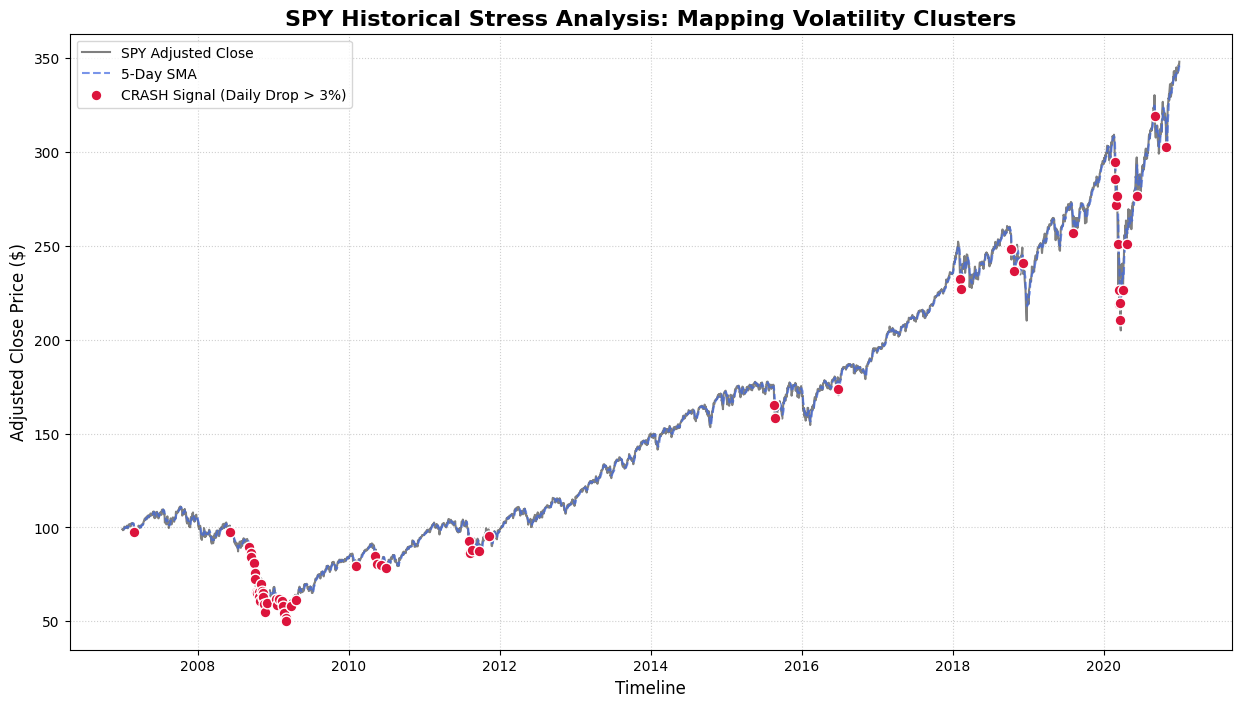

--- Analysis Summary ---
Total Crash Events Identified: 67
Maximum Single Day Drop: -10.94%


In [7]:
# 1. Download Historical Data
# Utilizing yfinance to fetch SPY data for GFC and COVID-19 periods
spy = yf.download('SPY', start='2007-01-01', end='2021-01-01')

# Flatten MultiIndex columns (Fix for recent yfinance updates)
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

# 2. Data Engineering & Risk Metric Calculation
# Ensure 'Adj Close' is prioritized for accurate return calculation
close_col = 'Adj Close' if 'Adj Close' in spy.columns else 'Close'

# Calculate Daily Returns and 5-Day Simple Moving Average (SMA)
spy['Daily_Return'] = spy[close_col].pct_change()
spy['SMA_5'] = spy[close_col].rolling(window=5).mean()

# 3. Risk Flagging Logic
# Define 'CRASH' signal as any day with a daily drop exceeding 3%
spy['Is_Crash'] = spy['Daily_Return'] <= -0.03

# 4. Visualization: Market Stress & Volatility Clusters
plt.figure(figsize=(15, 8))

# Plot SPY Price and Short-term Momentum (SMA 5)
plt.plot(spy.index, spy[close_col], label='SPY Adjusted Close', color='black', alpha=0.5)
plt.plot(spy.index, spy['SMA_5'], label='5-Day SMA', color='royalblue', linestyle='--', alpha=0.7)

# Identify and Plot 'CRASH' Events (Outlier Detection)
crash_days = spy[spy['Is_Crash'] == True]
plt.scatter(crash_days.index, crash_days[close_col],
            color='crimson', label='CRASH Signal (Daily Drop > 3%)',
            s=60, edgecolors='white', zorder=5)

# Professional Chart Styling
plt.title('SPY Historical Stress Analysis: Mapping Volatility Clusters', fontsize=16, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Adjusted Close Price ($)', fontsize=12)
plt.legend(loc='best', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Display the Final Analysis
plt.show()

# 5. Summary Statistics for Interview Prep
print(f"--- Analysis Summary ---")
print(f"Total Crash Events Identified: {crash_days.shape[0]}")
print(f"Maximum Single Day Drop: {spy['Daily_Return'].min():.2%}")